# Bloque 1 — Datos y parches

Prepara las imágenes (camera → entrenamiento 256×256, coins → prueba 128×128), extrae parches 8×8 con stride 4, los centra y muestrea 1500 parches de entrenamiento con RNG 42.

Implementación: `src/preprocesamiento.py` (fuente única). Productos: `datos.npz`, `config.json`, `versiones.txt`, `figuras/`. Documentación: `nota_datos.md`.

In [1]:
# Localiza la raíz del repositorio (local o Kaggle) y la añade a sys.path.
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/SarahVasquezM/ksvd-image-denoising.git"
REPO_REF = os.environ.get("KSVD_REPO_REF", "main")

def find_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "src" / "modelo.py").exists():
            return p
    if Path("/kaggle/working").exists():          # Kaggle: clonar el repositorio
        dest = Path("/kaggle/working/ksvd-image-denoising")
        if not dest.exists():
            subprocess.run(["git", "clone", "--depth", "1", "--branch", REPO_REF,
                            REPO_URL, str(dest)], check=True)
        return dest
    raise FileNotFoundError("No se encontró la raíz del repositorio")

ROOT = find_root()
sys.path.insert(0, str(ROOT))
import warnings
# Mostrar advertencias sin rutas absolutas de la máquina (no se suprime ninguna).
warnings.formatwarning = lambda msg, cat, filename, lineno, line=None: (
    f"{cat.__name__} ({Path(filename).name}:{lineno}): {msg}\n")
from threadpoolctl import threadpool_limits
from src.pipeline import DEFAULT_THREADS, paths
threadpool_limits(limits=DEFAULT_THREADS)     # evita sobresuscripción BLAS con matrices pequeñas
P = paths(ROOT)
print("Raíz del repositorio:", ROOT.name)

mkdir -p failed for path C:\Users\sarah\AppData\Local\matplotlib: [WinError 5] Acceso denegado: 'C:\\Users\\sarah\\AppData\\Local\\matplotlib'


Matplotlib created a temporary cache directory at C:\Users\sarah\AppData\Local\Temp\matplotlib-l5j5xczb because there was an issue with the default path (C:\Users\sarah\AppData\Local\matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Raíz del repositorio: ksvd-auditoria-final


## 1. Generar los productos del bloque

In [2]:
import json
from src.pipeline import run_block1
res = run_block1(ROOT)
print(json.dumps(res['summary'], indent=2))

{
  "n_patches_train_total": 3969,
  "n_patches_train_valid": 3969,
  "n_patches_train_discarded": 0,
  "n_patches_test_total": 961,
  "train_range": [
    0.008465512696419247,
    0.9994933599059728
  ],
  "test_range": [
    0.022977316821874896,
    0.8725645190356063
  ],
  "roundtrip_max_error_train": 1.1102230246251565e-16,
  "roundtrip_max_error_test": 1.1102230246251565e-16
}


## 2. Prueba obligatoria de ida y vuelta (extraer → reensamblar)

In [3]:
import numpy as np
from src.preprocesamiento import extract_patches, assemble_patches, load_dataset
d = load_dataset(P["datos"])
for name in ("train_image", "test_image"):
    image = d[name]
    Z, means, positions = extract_patches(image)
    recovered = assemble_patches(Z + means[None, :], positions, image.shape)
    err = np.max(np.abs(recovered - image))
    print(f"{name}: Z{Z.shape}, means{means.shape}, positions{positions.shape}, error máx = {err:.3e}")
    assert err < 1e-10

train_image: Z(64, 3969), means(3969,), positions(3969, 2), error máx = 1.110e-16
test_image: Z(64, 961), means(961,), positions(961, 2), error máx = 1.110e-16


## 3. Contrato de `datos.npz`

In [4]:
for k, v in d.items():
    print(f"{k:14s} shape={v.shape} dtype={v.dtype}")
Z, _, _ = extract_patches(d["train_image"])
assert np.array_equal(d["X_train"], Z[:, d["train_indices"]])
print("Índices referidos a la extracción completa:", Z.shape[1], "parches; únicos:", len(set(d["train_indices"])))

train_image    shape=(256, 256) dtype=float64
test_image     shape=(128, 128) dtype=float64
X_train        shape=(64, 1500) dtype=float64
train_indices  shape=(1500,) dtype=int64
Índices referidos a la extracción completa: 3969 parches; únicos: 1500


## 4. Configuración

In [5]:
print(json.dumps({k: v for k, v in res["config"].items()}, indent=2, ensure_ascii=False))

{
  "version_contrato": 1,
  "train_image_name": "camera",
  "test_image_name": "coins",
  "train_image_source": "skimage.data.camera()",
  "test_image_source": "skimage.data.coins()",
  "train_shape": [
    256,
    256
  ],
  "test_shape": [
    128,
    128
  ],
  "resize": {
    "anti_aliasing": true,
    "preserve_range": true
  },
  "conversion": "skimage.img_as_float64",
  "patch_size": 8,
  "stride": 4,
  "patch_order": "filas y luego columnas; flatten en orden C; un parche por columna",
  "centering": "se resta la media de cada parche (sin normalizar por la norma)",
  "min_patch_norm": 1e-08,
  "constant_threshold": 1e-08,
  "n_train_patches": 1500,
  "n_train": 1500,
  "n_atoms": 128,
  "atom_dim": 64,
  "n_iter": 8,
  "train_sparsity": 4,
  "eval_sparsities": [
    2,
    4,
    8
  ],
  "sigma": 0.0784313725490196,
  "sigma_255": 20,
  "data_range": 1.0,
  "seeds": {
    "data": 42,
    "model": 43,
    "noise": 44,
    "sampling": 42,
    "ksvd": 43
  },
  "images": {
    

## 5. Figuras de inspección

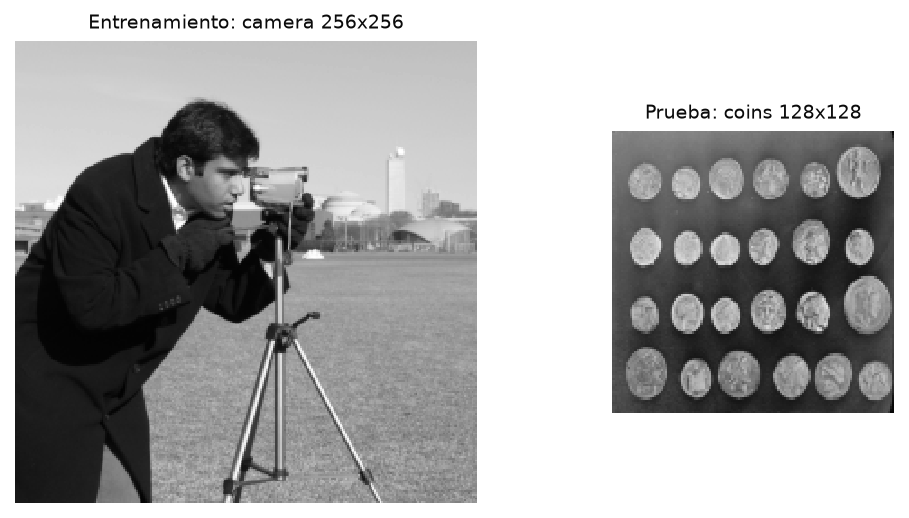

In [6]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / "01_datos/figuras/imagenes_camera_coins.png")))

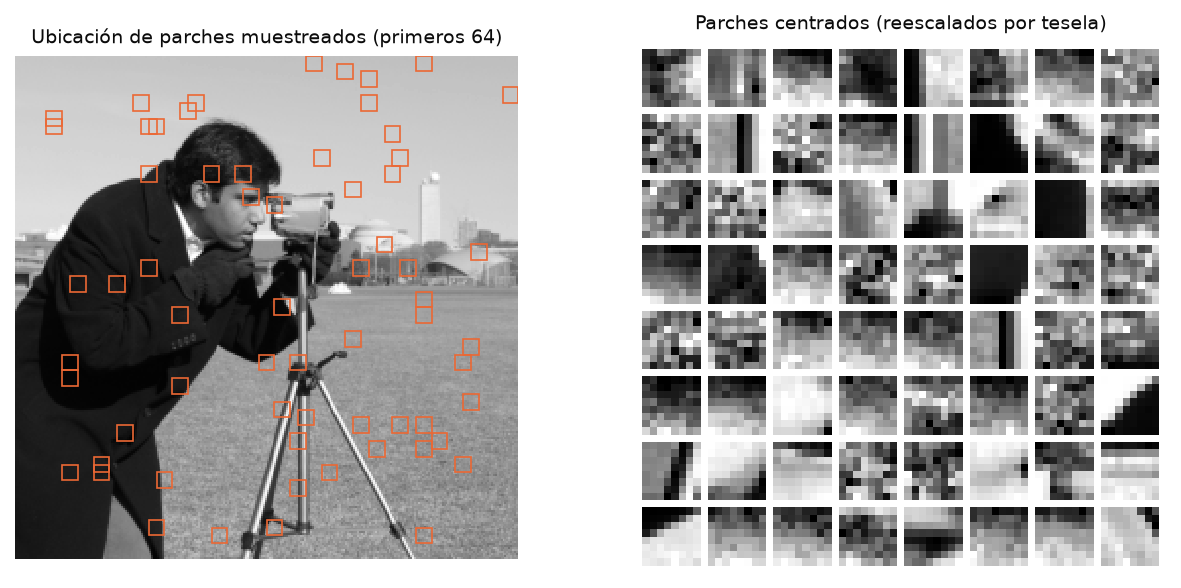

In [7]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / "01_datos/figuras/muestra_parches.png")))